In [1]:
# Tahap 1: Load Dataset

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset_tugas1_preprocessing.csv')
print(f"Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom".center(90))
df

                        Dataset berhasil dimuat: 99 baris, 8 kolom                        


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022/02/25,21.0
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021/04/14,20.0
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020/01/11,NaN
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022/01/29,22.0


In [2]:
#Tahap 2: Eksplorasi Awal (EDA)

print("\n--- Struktur & Tipe Data ---")
df.dtypes


--- Struktur & Tipe Data ---


ID                object
Nama              object
Jenis_Kelamin     object
Prodi             object
Status            object
Nilai_Akhir       object
Tanggal_Ujian     object
Umur             float64
dtype: object

In [3]:
print("--- Jumlah Nilai Hilang per Kolom ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
missing_df[missing_df['Jumlah Missing'] > 0]

--- Jumlah Nilai Hilang per Kolom ---


,Jumlah Missing,Persentase (%)
Nilai_Akhir,29,29.29
Umur,9,9.09


In [4]:
print("--- Statistik Deskriptif ---".center(90))
df.describe(include='all')

                               --- Statistik Deskriptif ---                               


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
count,99,99,99,99,99,70,99,90.000000
unique,99,10,2,4,4,5,97,NaN
top,MH001,Eka,Laki-laki,Teknik Komputer,Cuti,C,2020/02/05,NaN
freq,1,15,50,28,29,17,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.366667
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.763963
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000


In [9]:
#Tahap 3: Menangani Missing Values

# Imputasi Nilai_Akhir dengan modus
modus_nilai = df['Nilai_Akhir'].mode()[0]
df.fillna({'Nilai_Akhir': modus_nilai}, inplace=True)
print(f"Missing values Nilai_Akhir diisi dengan modus: {modus_nilai}")

# Imputasi Umur dengan median
median_umur = df['Umur'].median()
df.fillna({'Umur': median_umur}, inplace=True)
print(f"Missing values Umur diisi dengan median: {median_umur}")

print("\nMissing Values Sesudah:")
df[['Nilai_Akhir', 'Umur']].isnull().sum()

Missing values Nilai_Akhir diisi dengan modus: C
Missing values Umur diisi dengan median: 23.0

Missing Values Sesudah:


Nilai_Akhir    0
Umur           0
dtype: int64

In [6]:
df.dropna(axis=0)

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,C,13-04-2020,23.0
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022/02/25,21.0
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021/04/14,20.0
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020/01/11,23.0
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022/01/29,22.0


In [7]:
df.dropna(thresh=4)

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,C,13-04-2020,23.0
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022/02/25,21.0
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021/04/14,20.0
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020/01/11,23.0
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022/01/29,22.0


In [8]:
df.values

array([['MH001', 'Iwan', 'Laki-laki', 'Teknik Komputer', 'Aktif', 'C',
        '13-04-2020', 23.0],
       ['MH002', 'Eka', 'Perempuan', 'Teknik Komputer', 'Lulus', 'E',
        '2020/12/11', 28.0],
       ['MH003', 'Iwan', 'Laki-laki', 'Teknik Komputer', 'Aktif', 'C',
        '2021/11/21', 23.0],
       ['MH004', 'Eka', 'Perempuan', 'Teknik Komputer', 'Aktif', 'D',
        '2021/08/19', 18.0],
       ['MH005', 'Joko', 'Perempuan', 'Data Science', 'Aktif', 'C',
        '2020/01/05', 26.0],
       ['MH006', 'Gita', 'Perempuan', 'Teknik Komputer', 'Aktif', 'C',
        '2021/10/15', 20.0],
       ['MH007', 'Adi', 'Laki-laki', 'Data Science', 'DO', 'C',
        '2020/01/15', 21.0],
       ['MH008', 'Joko', 'Perempuan', 'Data Science', 'Cuti', 'C',
        '2020/09/16', 19.0],
       ['MH009', 'Iwan', 'Laki-laki', 'Informatika', 'Aktif', 'B',
        '2021/02/06', 25.0],
       ['MH010', 'Hana', 'Laki-laki', 'Informatika', 'Aktif', 'D',
        '2020/02/12', 19.0],
       ['MH011', 'Joko',

In [5]:
# Tahap 4: Normalisasi Format Tanggal

df['Tanggal_Ujian'] = pd.to_datetime(df['Tanggal_Ujian'], format='mixed', dayfirst=True)
print(f"Kolom Tanggal_Ujian berhasil dikonversi ke tipe: {df['Tanggal_Ujian'].dtype}".center(90))
df

             Kolom Tanggal_Ujian berhasil dikonversi ke tipe: datetime64[ns]              


,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2020-04-13,23.0
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020-12-11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2021-11-21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021-08-19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020-01-05,26.0
...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022-02-25,21.0
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021-04-14,20.0
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020-01-11,23.0
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022-01-29,22.0


In [12]:
df['Tahun'] = df['Tanggal_Ujian'].dt.year
df['Bulan'] = df['Tanggal_Ujian'].dt.month
df['Hari'] = df['Tanggal_Ujian'].dt.day
df['Nama_Hari'] = df['Tanggal_Ujian'].dt.day_name()
df

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur,Tahun,Bulan,Hari,Nama_Hari
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2020-04-13,23.0,2020,4,13,Monday
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020-12-11,28.0,2020,12,11,Friday
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,C,2021-11-21,23.0,2021,11,21,Sunday
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021-08-19,18.0,2021,8,19,Thursday
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020-01-05,26.0,2020,1,5,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...
94,MH095,Gita,Laki-laki,Teknik Komputer,Aktif,D,2022-02-25,21.0,2022,2,25,Friday
95,MH096,Adi,Laki-laki,Sistem Informasi,Lulus,C,2021-04-14,20.0,2021,4,14,Wednesday
96,MH097,Iwan,Laki-laki,Data Science,Lulus,D,2020-01-11,23.0,2020,1,11,Saturday
97,MH098,Eka,Perempuan,Data Science,Aktif,A,2022-01-29,22.0,2022,1,29,Saturday


In [6]:
# Tahap 5: Label Encoding

kolom_encode = ['Nama', 'Jenis_Kelamin', 'Prodi', 'Status', 'Nilai_Akhir']
le = LabelEncoder()

for col in kolom_encode:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n{col}: {mapping}")

print("\n" + "--- DataFrame setelah encoding (5 baris pertama) ---".center(90))
enc_cols = ['ID'] + [c + '_enc' for c in kolom_encode] + ['Umur', 'Tanggal_Ujian']
df[enc_cols]


Nama: {'Adi': np.int32(0), 'Budi': np.int32(1), 'Citra': np.int32(2), 'Dina': np.int32(3), 'Eka': np.int32(4), 'Farhan': np.int32(5), 'Gita': np.int32(6), 'Hana': np.int32(7), 'Iwan': np.int32(8), 'Joko': np.int32(9)}

Jenis_Kelamin: {'Laki-laki': np.int32(0), 'Perempuan': np.int32(1)}

Prodi: {'Data Science': np.int32(0), 'Informatika': np.int32(1), 'Sistem Informasi': np.int32(2), 'Teknik Komputer': np.int32(3)}

Status: {'Aktif': np.int32(0), 'Cuti': np.int32(1), 'DO': np.int32(2), 'Lulus': np.int32(3)}

Nilai_Akhir: {'A': np.int32(0), 'B': np.int32(1), 'C': np.int32(2), 'D': np.int32(3), 'E': np.int32(4)}

                   --- DataFrame setelah encoding (5 baris pertama) ---                   


,ID,Nama_enc,Jenis_Kelamin_enc,Prodi_enc,Status_enc,Nilai_Akhir_enc,Umur,Tanggal_Ujian
0,MH001,8,0,3,0,2,23.0,2020-04-13
1,MH002,4,1,3,3,4,28.0,2020-12-11
2,MH003,8,0,3,0,2,23.0,2021-11-21
3,MH004,4,1,3,0,3,18.0,2021-08-19
4,MH005,9,1,0,0,2,26.0,2020-01-05
...,...,...,...,...,...,...,...,...
94,MH095,6,0,3,0,3,21.0,2022-02-25
95,MH096,0,0,2,3,2,20.0,2021-04-14
96,MH097,8,0,0,3,3,23.0,2020-01-11
97,MH098,4,1,0,0,0,22.0,2022-01-29


In [7]:
# Tahap 6: Split Data (80% Train / 20% Test)

feature_cols = [c + '_enc' for c in kolom_encode] + ['Umur']
# Gunakan Status_enc sebagai target, sisanya fitur
X = df[[c for c in feature_cols if c != 'Status_enc']]
y = df['Status_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Total data   : {len(df)} baris")
print(f"Data latih   : {len(X_train)} baris ({len(X_train)/len(df)*100:.0f}%)")
print(f"Data uji     : {len(X_test)} baris  ({len(X_test)/len(df)*100:.0f}%)")

Total data   : 99 baris
Data latih   : 79 baris (80%)
Data uji     : 20 baris  (20%)


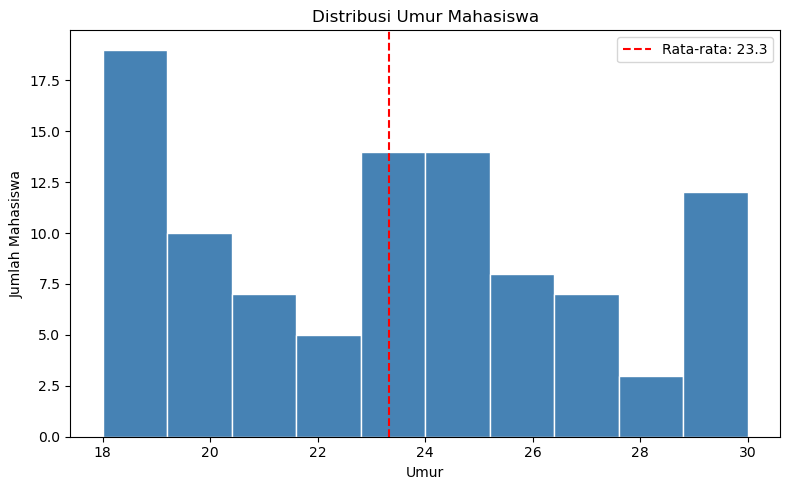

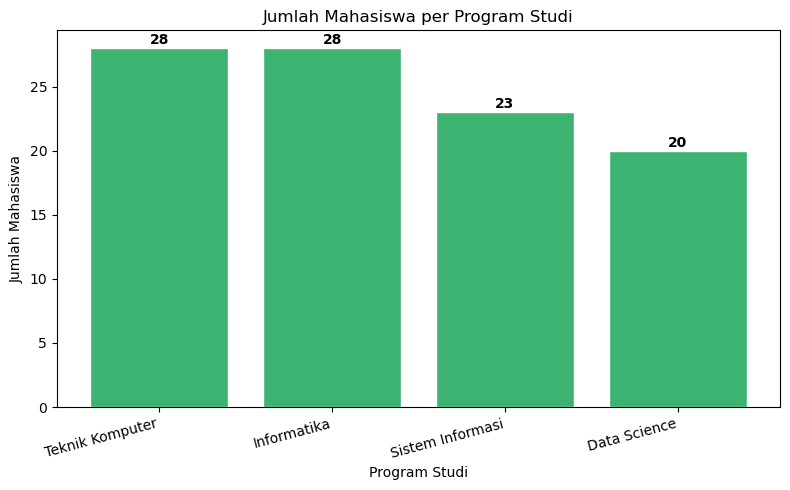

In [8]:
# Tahap 7: Visualisasi

# Imputasi agar tidak ada missing (lanjutan Tahap 3)
df['Nilai_Akhir'] = df['Nilai_Akhir'].fillna(df['Nilai_Akhir'].mode()[0])
df['Umur'] = df['Umur'].fillna(df['Umur'].median())
 
# Histogram Umur
plt.figure(figsize=(8, 5))
plt.hist(df['Umur'], bins=10, color='steelblue', edgecolor='white')
plt.axvline(df['Umur'].mean(), color='red', linestyle='--',
            label=f"Rata-rata: {df['Umur'].mean():.1f}")
plt.title('Distribusi Umur Mahasiswa')
plt.xlabel('Umur')
plt.ylabel('Jumlah Mahasiswa')
plt.legend()
plt.tight_layout()
plt.show()
 
# Bar Chart Jumlah Mahasiswa per Prodi 
prodi_counts = df['Prodi'].value_counts()
 
plt.figure(figsize=(8, 5))
plt.bar(prodi_counts.index, prodi_counts.values, color='mediumseagreen', edgecolor='white')
plt.title('Jumlah Mahasiswa per Program Studi')
plt.xlabel('Program Studi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(prodi_counts.values):
    plt.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
